In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def analizza_e_plotta(file_path):
    """
    Legge i dati di simulazione, esegue regressione lineare e genera il plot.
    """
    # Definizione manuale delle colonne data la spaziatura irregolare dell'intestazione
    nomi_colonne = [
        'Pres', 'moltiplicatore', 'PERC_water', 'Arricch_MAX',
        'Arricch_min', 'T_WATER', 'T_FUEL', 'K_max', 'std_k_max',
        'K_auto', 'std_k_auto', 'Compatibilità'
    ]
    
    # Lettura del file: ignora le prime 3 righe testuali, usa spazi multipli come separatore
    df = pd.read_csv(file_path, sep=r'\s+', skiprows=3, names=nomi_colonne, engine='python')
    
    # Estrazione array per la regressione
    x_data = df['Arricch_min'].values
    y_data = df['Arricch_MAX'].values

    # Calcolo regressione lineare (polinomio di grado 1)
    a,b,c = np.polyfit(x_data, y_data, 2)

    # Vettori per l'estrapolazione del modello
    x_pred = np.array([1,2,3,4,5,6, 7, 8, 9, 10,11,12,13,14,15,16,17,18,19,20])
    y_pred = a * x_pred**2 + b*x_pred  + c

    # Output analitico a terminale
    print(f"Equazione della retta: y = {a:.3f}x^2 + {b:.3f}x + {c:.3f}\n")
    print("Valori previsti:")
    for x, y in zip(x_pred, y_pred):
        print(f"x = {x} -> y = {y:.2f}")

    # Configurazione della Figura
    fig, ax = plt.subplots(figsize=(16, 10))

   # Plot dei dati estratti (pallini neri)
    ax.scatter(x_data, y_data, color='#000000', s=80, zorder=5, label='Dati Simulazione')

    # Plot della retta di regressione
    x_full = x_pred
    y_full = a * x_full**2 + b*x_full + c
    ax.plot(x_full, y_full, color='#789DD1', linestyle='-', linewidth=2, zorder=4, 
            label=f'Regressione Lineare ($y={a:.2f}x^2+{b:.2f}x+{c:.2f}$)')

    # Plot dei valori previsti (marcatore quadrato azzurro)
    ax.scatter(x_pred, y_pred, color='#789DD1', marker='s', s=80, zorder=6, 
               edgecolor='#000000', label='Valori Estrapolati')

    # Formattazione Titolo e Assi
    ax.set_title('Regressione: Arricchimento INT in funzione di Arricchimento EXT; per matching k_max = 0.97547 con pitch = x1', 
                 fontsize=16, fontweight='bold', color='#2F4F4F', pad=20)
    ax.set_xlabel('Arricchimento EXT', fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.set_ylabel('Arricchimento INT', fontsize=14, fontweight='bold', color='#2F4F4F')

    # Formattazione Tick
    ax.tick_params(axis='both', which='major', labelsize=12, labelcolor='#2F4F4F')

    # Setup della griglia avanzata
    ax.minorticks_on()
    ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
    ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')

    # Setup Legenda
    ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

    plt.tight_layout()
    plt.savefig('regressione_simulazione.png', dpi=300)
    plt.show()

    return a,b,c

a,b,c = analizza_e_plotta('../result_final.txt')

ParserError: Expected 16 fields in line 11, saw 24. Error could possibly be due to quotes being ignored when a multi-char delimiter is used.

--- Analisi Rette: Medie  ---

Retta 1 [P_i(1, 15.44) -> P_f(11, 1.00)]:
  Media discreta = 8.222 

Retta 2 [P_i(1, 12.85) -> P_f(11, 2.00)]:
  Media discreta = 7.423 

Retta 3 [P_i(1, 10.50) -> P_f(11, 3.00)]:
  Media discreta = 6.749 

Retta 4 [P_i(1, 8.40) -> P_f(11, 4.00)]:
  Media discreta = 6.200 

Retta 5 [P_i(1, 6.55) -> P_f(11, 5.00)]:
  Media discreta = 5.775 

Retta 6 [P_i(1, 4.95) -> P_f(11, 6.00)]:
  Media discreta = 5.474 

Retta 7 [P_i(1, 3.60) -> P_f(11, 7.00)]:
  Media discreta = 5.299 

Retta 8 [P_i(1, 2.50) -> P_f(11, 8.00)]:
  Media discreta = 5.248 

Retta 9 [P_i(1, 1.64) -> P_f(11, 9.00)]:
  Media discreta = 5.321 

Retta 10 [P_i(1, 1.04) -> P_f(11, 10.00)]:
  Media discreta = 5.520 

Retta 11 [P_i(1, 0.68) -> P_f(11, 11.00)]:
  Media discreta = 5.842 

Retta 12 [P_i(1, 0.58) -> P_f(11, 12.00)]:
  Media discreta = 6.290 

Retta 13 [P_i(1, 0.72) -> P_f(11, 13.00)]:
  Media discreta = 6.862 

Retta 14 [P_i(1, 1.12) -> P_f(11, 14.00)]:
  Media discreta = 7.559 

Rett

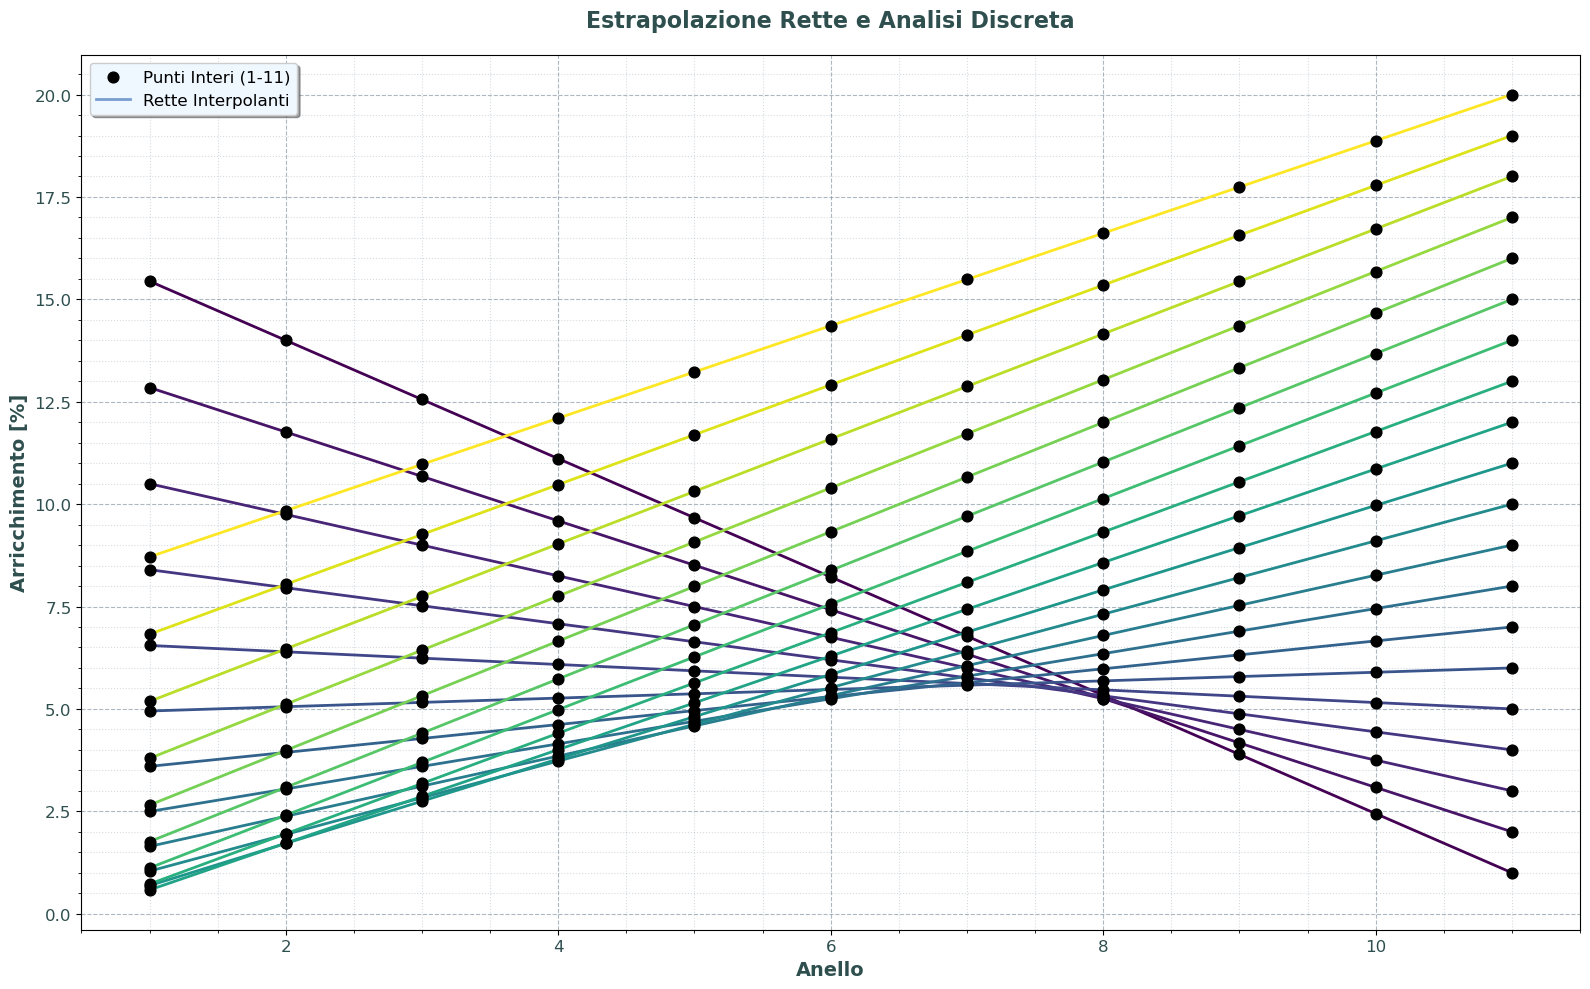

array([ 8.22186905,  7.42314286,  6.74903571,  6.19954762,  5.77467857,
        5.47442857,  5.29879762,  5.24778571,  5.32139286,  5.51961905,
        5.84246429,  6.28992857,  6.8620119 ,  7.55871429,  8.38003571,
        9.32597619, 10.39653571, 11.59171429, 12.9115119 , 14.35592857])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def plot_rette_discrete(x_pred, y_pred):
    """
    Traccia rette da (1, y_pred) a (11, x_pred), evidenzia i punti discreti,
    e calcola media e integrale per ciascuna retta.
    """
    print("--- Analisi Rette: Medie  ---\n")
    
    # Configurazione della Figura
    fig, ax = plt.subplots(figsize=(16, 10))

    media_vect = np.array([])
    
    # Array dei punti discreti
    x_discrete = np.arange(1, 12)
    
    # Colormap per differenziare le rette
    colors = cm.viridis(np.linspace(0, 1, len(x_pred)))
    
    for i, (x_p, y_p) in enumerate(zip(x_pred, y_pred)):
        y_start = y_p
        y_end = x_p
        
        # Calcolo coefficienti retta: y = m*x + q
        m = (y_end - y_start) / 10.0
        q = y_start - m * 1.0
        
        # Valutazione della retta sui punti discreti
        y_discrete = m * x_discrete + q
        
        # Operazioni matematiche richieste
        media_y = np.mean(y_discrete)
        
        print(f"Retta {i+1} [P_i(1, {y_start:.2f}) -> P_f(11, {y_end:.2f})]:")
        print(f"  Media discreta = {media_y:.3f} \n")

        media_vect = np.append(media_vect, media_y)
        
        # Plot della retta (colori differenti)
        ax.plot(x_discrete, y_discrete, color=colors[i], linestyle='-', linewidth=2, zorder=4)
        
        # Plot dei marker (pallini neri come da standard richiesto)
        ax.scatter(x_discrete, y_discrete, color='#000000', s=60, zorder=5)

    # Formattazione Titolo e Assi
    ax.set_title('Estrapolazione Rette e Analisi Discreta', 
                 fontsize=16, fontweight='bold', color='#2F4F4F', pad=20)
    ax.set_xlabel('Anello', fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.set_ylabel('Arricchimento [%]', fontsize=14, fontweight='bold', color='#2F4F4F')

    # Formattazione Tick
    ax.tick_params(axis='both', which='major', labelsize=12, labelcolor='#2F4F4F')

    # Setup della griglia avanzata
    ax.minorticks_on()
    ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
    ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')

    # Setup Legenda (Aggiunta manuale per rispettare stile univoco)
    ax.scatter([], [], color='#000000', s=60, label='Punti Interi (1-11)')
    ax.plot([], [], color='#789DD1', linestyle='-', linewidth=2, label='Rette Interpolanti')
    ax.legend(loc='upper left', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

    plt.tight_layout()
    plt.show()

    return media_vect

x_pred = np.array([1,2,3,4,5,6, 7, 8, 9, 10,11,12,13,14,15,16,17,18,19,20])
y_pred = a* x_pred**2 + b*x_pred  + c

plot_rette_discrete(x_pred, y_pred)